In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/insurance (1).csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
data.shape

(1338, 7)

In [ ]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
data.nunique()

,0
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337


correlation

In [ ]:
numeric_data = data.select_dtypes(include = np.number)
numeric_data.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


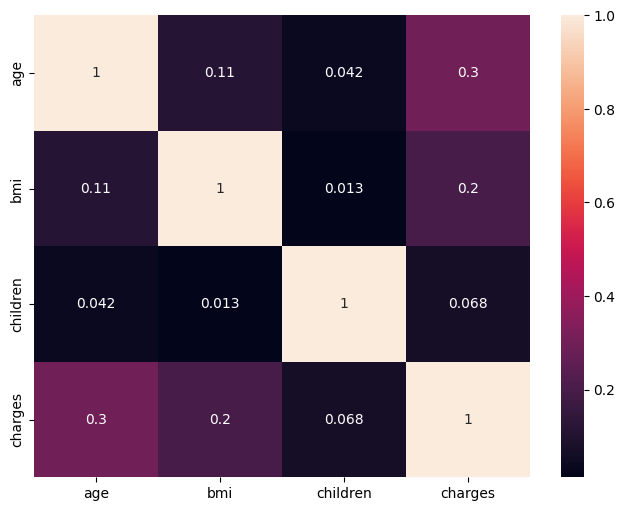

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(),annot = True)
plt.show()

boxplot

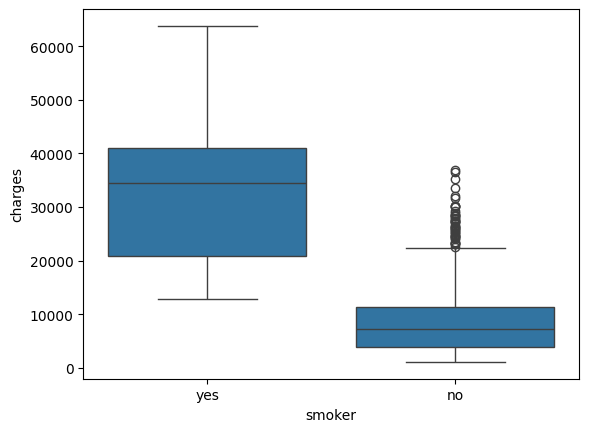

In [ ]:
sns.boxplot(x="smoker",y="charges",data=data)
plt.show()

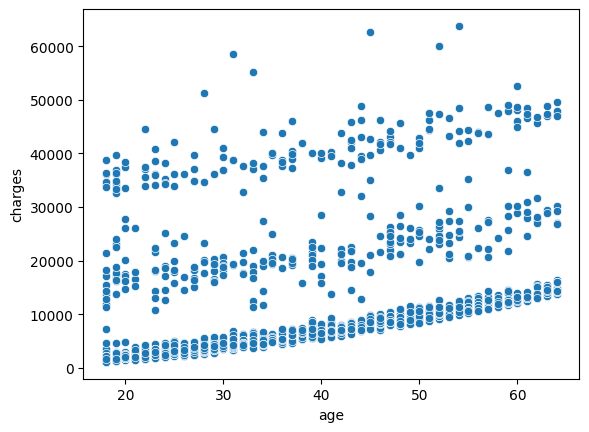

In [ ]:
sns.scatterplot(x="age",y="charges",data= data)
plt.show()

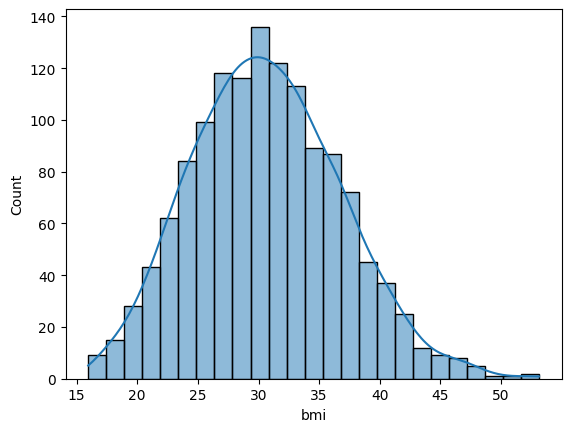

In [ ]:
sns.histplot(data["bmi"],kde = True)
plt.show()

preprocessing

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:
data["sex"]=le.fit_transform(data["sex"])

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [ ]:
data["smoker"]=le.fit_transform(data["smoker"])

In [ ]:
data["region"] = le.fit_transform(data["region"])

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:
x = data.drop("charges",axis=1)

In [ ]:
y=data["charges"]

split data

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state=42)

model selection

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

model prediction

In [ ]:
prediction = model.predict(x_test)

In [ ]:
prediction[:4]

array([ 8924.40724442,  7116.29501758, 36909.01352144,  9507.87469118])

model evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score


In [ ]:
mae = mean_absolute_error(y_test,prediction)
print("mean absolute eroor is :",mae)

mean absolute eroor is : 4186.508898366433


In [ ]:
r2 = r2_score(y_test,prediction)
print("r2 of the model is :",r2)

r2 of the model is : 0.7833463107364539


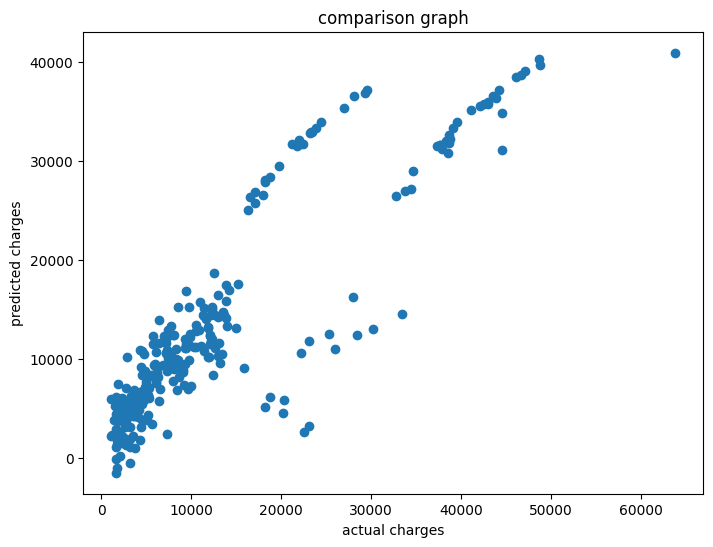

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,prediction)
plt.xlabel("actual charges")
plt.ylabel("predicted charges")
plt.title("comparison graph")
plt.show()

coefficients

In [ ]:
coef_df= pd.DataFrame(model.coef_,x.columns,columns=["coefficients"])
coef_df

,coefficients
age,257.056264
sex,-18.791457
bmi,335.781491
children,425.091456
smoker,23647.818096
region,-271.284266


save model

In [ ]:
import pickle

In [ ]:
pickle.dump(model,open("insurance_model.pkl","wb"))

In [ ]:
loaded_model = pickle.load(open("insurance_model.pkl","rb"))

In [ ]:
sample_data = [[19, 0, 27.9, 0, 1, 3]]
prediction = loaded_model.predict(sample_data)

print(prediction)

[25139.73133878]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
from google.colab import files
files.download("insurance_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>